In [63]:
import matplotlib.pyplot as plt
import shap
from catboost import Pool
#from catboost.utils import get_tree_plot
import numpy as np
from catboost_cv import PhotoZCatBoostPipeline
from catboost import CatBoostRegressor, Pool
import scienceplots
import pandas as pd
plt.style.use(['science', 'notebook', 'grid'])  # Use the science plots style
import shap
from astropy.table import Table,vstack,join,unique
import fitsio
from astropy.coordinates import SkyCoord
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from Metrics import PhotoZMetrics
import astropy.units as u
shap.initjs()


In [5]:
# cfg =     PhotoZCatBoostPipeline.load_config('/user/animesh.sah/DESI_PECVEL/ML_photoz/ZHOUETAL/config_catboost.yaml')
# cv_pipe = PhotoZCatBoostPipeline(feature_names=cfg['features'])
# DR1, legacy = cv_pipe.load_astronomical_data(cfg)
# legacy = cv_pipe.compute_magnitudes(legacy)
# legacy_filtered, DR1_filtered = cv_pipe.filter_data(legacy, DR1, feature_names = cfg['features'])
# X, y = cv_pipe.prepare_ml_data(legacy_filtered, DR1_filtered)

cfg =     PhotoZCatBoostPipeline.load_config('/user/animesh.sah/DESI_PECVEL/ML_photoz/runs/RUN2_north/logs/config_used.yaml')
cv_pipe = PhotoZCatBoostPipeline(feature_names=cfg['features'])
DR1, legacy = cv_pipe.load_astronomical_data(cfg)
legacy = cv_pipe.compute_magnitudes(legacy)
legacy_filtered, DR1_filtered = cv_pipe.filter_data(legacy, DR1, feature_names = cfg['features'])
X, y = cv_pipe.prepare_ml_data(legacy_filtered, DR1_filtered)





INFO:catboost_cv:Config loaded from /user/animesh.sah/DESI_PECVEL/ML_photoz/runs/RUN2_north/logs/config_used.yaml
INFO:catboost_cv:Initialized PhotoZ pipeline using CPU
INFO:catboost_cv:Number of CPUs available: 32
INFO:catboost_cv:Loading astronomical data...
INFO:catboost_cv:Loading data for the region: north
INFO:catboost_cv:Data loaded in 6.30 seconds
INFO:catboost_cv:Computing magnitudes and colors...
/user/animesh.sah/DESI_PECVEL/ML_photoz/catboost_cv.py:207: RuntimeWarning: invalid value encountered in divide
  legacy['MODEL_WEIGHT'] = legacy['DCHISQ'][:,2]/(legacy['DCHISQ'][:,2]+legacy['DCHISQ'][:,3])    #(p = dchi2dev/(dchi2dev+dchi2exp))
INFO:catboost_cv:Applying data quality cuts...
INFO:catboost_cv:Using features: ['MAG_R', 'MAG_G', 'MAG_GR', 'MAG_RZ', 'MAG_W1W2', 'MAG_ZW1', 'MAG_ZW2', 'R_CIRC', 'SHAPE_R', 'MODEL_WEIGHT', 'BBA', 'SERSIC', 'MAG_W1', 'MAG_W3', 'MAG_W1W3', 'MAG_RW2', 'MAG_GW1', 'MAG_GW3']


Available Columns: ['BRICKID', 'BRICKNAME', 'OBJID', 'TYPE', 'RA', 'DEC', 'DCHISQ', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FLUX_W3', 'FLUX_W4', 'FLUX_IVAR_G', 'FLUX_IVAR_R', 'FLUX_IVAR_Z', 'FLUX_IVAR_W1', 'FLUX_IVAR_W2', 'FLUX_IVAR_W3', 'MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2', 'MW_TRANSMISSION_W3', 'MW_TRANSMISSION_W4', 'NOBS_G', 'NOBS_R', 'NOBS_Z', 'FRACFLUX_G', 'FRACFLUX_R', 'FRACFLUX_Z', 'FRACMASKED_G', 'FRACMASKED_R', 'FRACMASKED_Z', 'FRACIN_G', 'FRACIN_R', 'FRACIN_Z', 'PSFSIZE_G', 'PSFSIZE_R', 'PSFSIZE_Z', 'PSFDEPTH_G', 'PSFDEPTH_R', 'PSFDEPTH_Z', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'FIBERFLUX_G', 'FIBERFLUX_R', 'FIBERFLUX_Z', 'GAIA_PHOT_G_MEAN_MAG', 'MASKBITS', 'SERSIC', 'Z_PHOT_MEAN', 'Z_PHOT_MEDIAN', 'Z_PHOT_L95', 'Z_SPEC', 'SURVEY', 'MAG_G', 'MAG_R', 'MAG_Z', 'MAG_W1', 'MAG_W2', 'MAG_W3', 'MAG_GR', 'MAG_RZ', 'MAG_GZ', 'MAG_W1W2', 'MAG_W2W3', 'MAG_W1W3', 'MAG_RW1', 'MAG_RW2', 'MAG_RW3', 'MAG_G

INFO:catboost_cv:Filtered from 1858728 to 1306929 objects
INFO:catboost_cv:Filtered from 1858728 to 1305941 objects for unique TARGETID
INFO:catboost_cv:Feature matrix shape: (1305941, 18)
INFO:catboost_cv:Target range: [0.010, 0.500]


In [6]:
# modelsouth = CatBoostRegressor() 
# modelsouth.load_model("/user/animesh.sah/DESI_PECVEL/ML_photoz/catboost_south_noweight_1773740706.cbm")
modelnorth =  CatBoostRegressor() 
modelnorth.load_model("/user/animesh.sah/DESI_PECVEL/ML_photoz/runs/RUN2_north/models/catboost_north_noweight.cbm")

In [7]:
X_train, X_val, X_test, y_train, y_val, y_test = cv_pipe.create_data_splits(X, y)

INFO:catboost_cv:Creating data splits...
INFO:catboost_cv:Train: 979455, Val: 163243, Test: 163243


In [ ]:
# cv_pipe.load_pretrained_model('/user/animesh.sah/DESI_PECVEL/ML_photoz/catboost_south_noweight_1773740706.cbm')
# cv_pipe.evaluate_model(False)


INFO:catboost_cv:Loading model from /user/animesh.sah/DESI_PECVEL/ML_photoz/catboost_south_noweight_1773740706.cbm
INFO:catboost_cv:Loaded model with 9000 iterations
INFO:catboost_cv:Evaluating model performance...



MODEL EVALUATION RESULTS

TEST SET METRICS:
------------------------------
MAE:  0.022137
MSE:  0.001055
RMSE: 0.032479
R²:   0.905329

CUSTOM PHOTOZ METRICS (TEST):
{'bias': 3.193818908371873e-05, 'sigma': 0.02598274970768132, 'sigma_NMAD': 0.017990461487046278, 'delta(0.3)': 0.9999797119091094, 'outlier_fraction(0.15)': 0.0012822073442889023}

VALIDATION SET METRICS:
------------------------------
MAE:  0.022216
MSE:  0.001056
RMSE: 0.032496
R²:   0.905548

CUSTOM PHOTOZ METRICS (VALIDATION):
{'bias': -2.5017608717688093e-05, 'sigma': 0.026013177251563113, 'sigma_NMAD': 0.01808453209004898, 'delta(0.3)': 0.9999857983363766, 'outlier_fraction(0.15)': 0.0012091702170825725}

PERFORMANCE COMPARISON:
------------------------------
Test RMSE:       0.032479
Validation RMSE: 0.032496
Difference:      0.000017
✅ Consistent performance across datasets


{'test': {'mae': 0.02213721206001045,
  'mse': 0.0010548768475643702,
  'rmse': 0.032478867707547474,
  'r2': 0.9053294933823832,
  'photoz': <Metrics.PhotoZMetrics at 0x74540dc782b0>},
 'validation': {'mae': 0.022215595909472436,
  'mse': 0.001055978469869934,
  'rmse': 0.032495822344878945,
  'r2': 0.9055484189749202,
  'photoz': <Metrics.PhotoZMetrics at 0x74540dc794e0>}}

In [10]:
explainer = shap.TreeExplainer(modelnorth)

In [18]:
sample_idx = np.random.choice(len(X_test), 10000, replace=False)
X_sample = X_test[sample_idx]


In [19]:
shap_values = explainer.shap_values(X_sample)

In [22]:
len(cfg['features']), X.shape

(18, (1305941, 18))

In [23]:
shap.plots.force(explainer.expected_value,shap_values[0, ...])


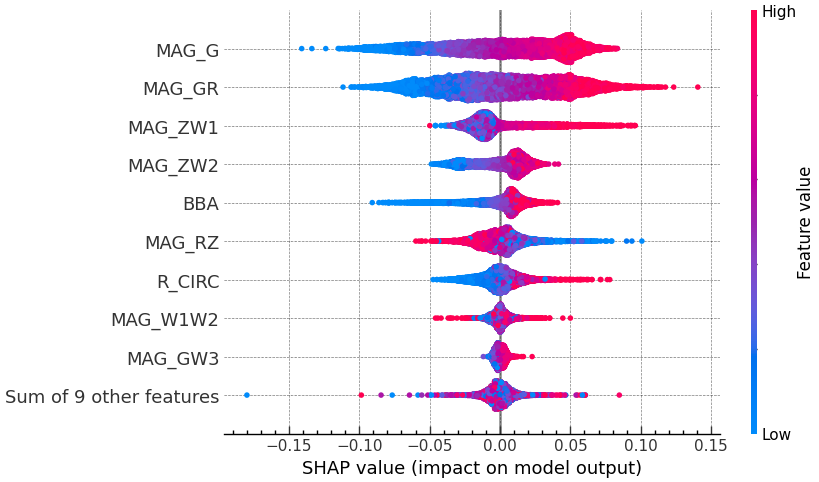

In [24]:
base_values = np.repeat(explainer.expected_value, shap_values.shape[0])

shap_exp = shap.Explanation(
    values=shap_values,
    base_values=base_values,
    data=X_sample,
    feature_names=cfg['features']
)

shap.plots.beeswarm(shap_exp)

In [29]:
north = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/table_north_unique.fits')[1].read())
south = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/table_south_unique.fits')[1].read())
DR1_SGC=Table(fitsio.FITS('../desi_dr1_SGC.fits')[1].read())
DR1_NGC=Table(fitsio.FITS('../desi_dr1_NGC.fits')[1].read())
DR1=vstack([DR1_NGC,DR1_SGC])

In [30]:
coords_dr = SkyCoord(ra=DR1['RA']*u.deg, dec=DR1['DEC']*u.deg)
coords_south = SkyCoord(ra=south['RA']*u.deg, dec=south['DEC']*u.deg)
idx, d2d, _ = coords_south.match_to_catalog_sky(coords_dr)
matched_south = south[d2d < 1*u.arcsec]
matched_DR_south = DR1[idx[d2d < 1*u.arcsec]]
coords_north = SkyCoord(ra=north['RA']*u.deg, dec=north['DEC']*u.deg)
idx, d2d, _ = coords_north.match_to_catalog_sky(coords_dr)
matched_north = north[d2d < 1*u.arcsec]
matched_DR_north = DR1[idx[d2d < 1*u.arcsec]]

In [57]:
list(np.hstack([cfg['features'], 'Z_PHOT_MEDIAN']))

['MAG_R',
 'MAG_G',
 'MAG_GR',
 'MAG_RZ',
 'MAG_W1W2',
 'MAG_ZW1',
 'MAG_ZW2',
 'R_CIRC',
 'SHAPE_R',
 'MODEL_WEIGHT',
 'BBA',
 'SERSIC',
 'MAG_W1',
 'MAG_W3',
 'MAG_W1W3',
 'MAG_RW2',
 'MAG_GW1',
 'MAG_GW3',
 'Z_PHOT_MEDIAN']

In [85]:
data_instance = PhotoZCatBoostPipeline(feature_names=cfg['features'])
matched_north = data_instance.compute_magnitudes(matched_north)
matched_north_photoz_filtered,  DR1_north_photoz_filtered= data_instance.filter_data(matched_north, matched_DR_north, feature_names =list(np.hstack([cfg['features'], 'Z_PHOT_MEDIAN'])))
matched_north_filtered, DR1_north_filtered = data_instance.filter_data(matched_north, matched_DR_north, feature_names = cfg['features'])
X_north, y_north = cv_pipe.prepare_ml_data(matched_north_filtered, DR1_north_filtered)


INFO:catboost_cv:Initialized PhotoZ pipeline using CPU
INFO:catboost_cv:Number of CPUs available: 32
INFO:catboost_cv:Computing magnitudes and colors...
/user/animesh.sah/DESI_PECVEL/ML_photoz/catboost_cv.py:207: RuntimeWarning: invalid value encountered in divide
  legacy['MODEL_WEIGHT'] = legacy['DCHISQ'][:,2]/(legacy['DCHISQ'][:,2]+legacy['DCHISQ'][:,3])    #(p = dchi2dev/(dchi2dev+dchi2exp))
INFO:catboost_cv:Applying data quality cuts...
INFO:catboost_cv:Using features: ['MAG_R', 'MAG_G', 'MAG_GR', 'MAG_RZ', 'MAG_W1W2', 'MAG_ZW1', 'MAG_ZW2', 'R_CIRC', 'SHAPE_R', 'MODEL_WEIGHT', 'BBA', 'SERSIC', 'MAG_W1', 'MAG_W3', 'MAG_W1W3', 'MAG_RW2', 'MAG_GW1', 'MAG_GW3', 'Z_PHOT_MEDIAN']
INFO:catboost_cv:Filtered from 37455 to 24285 objects
INFO:catboost_cv:Filtered from 37455 to 24285 objects for unique TARGETID
INFO:catboost_cv:Applying data quality cuts...
INFO:catboost_cv:Using features: ['MAG_R', 'MAG_G', 'MAG_GR', 'MAG_RZ', 'MAG_W1W2', 'MAG_ZW1', 'MAG_ZW2', 'R_CIRC', 'SHAPE_R', 'MODEL_WEI

Available Columns: ['BRICKID', 'BRICKNAME', 'OBJID', 'TYPE', 'RA', 'DEC', 'DCHISQ', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FLUX_W3', 'FLUX_W4', 'FLUX_IVAR_G', 'FLUX_IVAR_R', 'FLUX_IVAR_Z', 'FLUX_IVAR_W1', 'FLUX_IVAR_W2', 'FLUX_IVAR_W3', 'MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2', 'MW_TRANSMISSION_W3', 'MW_TRANSMISSION_W4', 'NOBS_G', 'NOBS_R', 'NOBS_Z', 'FRACFLUX_G', 'FRACFLUX_R', 'FRACFLUX_Z', 'FRACMASKED_G', 'FRACMASKED_R', 'FRACMASKED_Z', 'FRACIN_G', 'FRACIN_R', 'FRACIN_Z', 'PSFSIZE_G', 'PSFSIZE_R', 'PSFSIZE_Z', 'PSFDEPTH_G', 'PSFDEPTH_R', 'PSFDEPTH_Z', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'FIBERFLUX_G', 'FIBERFLUX_R', 'FIBERFLUX_Z', 'GAIA_PHOT_G_MEAN_MAG', 'MASKBITS', 'SERSIC', 'R_CIRC', 'MAG_G', 'MAG_R', 'MAG_Z', 'MAG_W1', 'FIBERMAG_G', 'FIBERMAG_R', 'FIBERMAG_Z', 'MAG_NOEXT_G', 'MAG_NOEXT_R', 'MAG_NOEXT_Z', 'Z_PHOT_MEDIAN', 'Z_PHOT_L95', 'MAG_W2', 'MAG_W3', 'MAG_GR', 'MAG_RZ', 'MAG_GZ', 'MAG_W1W2', '

In [59]:
Z_pred_north = modelnorth.predict(X_north)

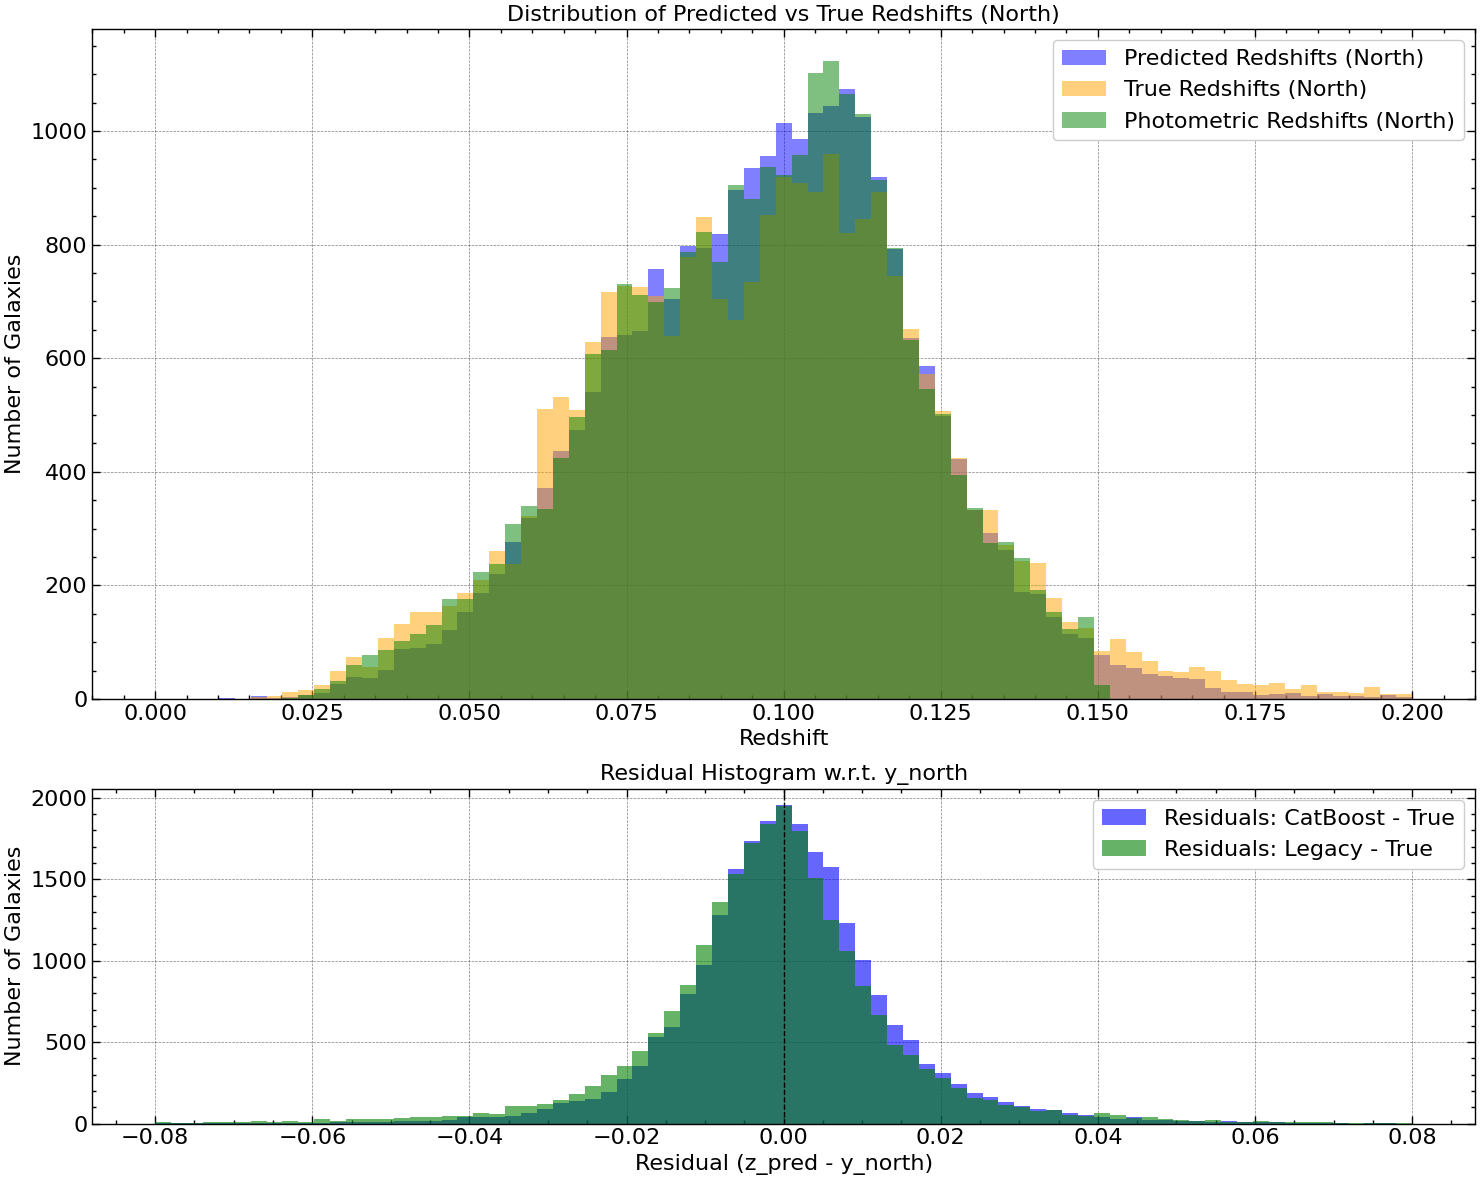

In [66]:
bins = np.linspace(0, 0.2, 80)
res_bins = np.linspace(-0.08, 0.08, 80)

legacy_photoz = np.asarray(matched_north_photoz_filtered['Z_PHOT_MEDIAN'])
valid_legacy = np.isfinite(legacy_photoz) & (legacy_photoz > 0)

res_cb = Z_pred_north - y_north
res_legacy = legacy_photoz[valid_legacy] - y_north[valid_legacy]

fig, (ax0, ax1) = plt.subplots(
    2, 1, figsize=(15, 12), gridspec_kw={"height_ratios": [2, 1]}
)

ax0.hist(Z_pred_north, bins=bins, alpha=0.5, label='Predicted Redshifts (North)', color='blue')
ax0.hist(y_north, bins=bins, alpha=0.5, label='True Redshifts (North)', color='orange')
ax0.hist(legacy_photoz[valid_legacy], bins=bins, alpha=0.5, label='Photometric Redshifts (North)', color='green')
ax0.set_xlabel('Redshift')
ax0.set_ylabel('Number of Galaxies')
ax0.set_title('Distribution of Predicted vs True Redshifts (North)')
ax0.legend()

ax1.hist(res_cb, bins=res_bins, alpha=0.6, label='Residuals: CatBoost - True', color='blue')
ax1.hist(res_legacy, bins=res_bins, alpha=0.6, label='Residuals: Legacy - True', color='green')
ax1.axvline(0, color='black', linestyle='--', linewidth=1)
ax1.set_xlabel('Residual (z_pred - y_north)')
ax1.set_ylabel('Number of Galaxies')
ax1.set_title('Residual Histogram w.r.t. y_north')
ax1.legend()

plt.tight_layout()
plt.show()

In [70]:
len(y_north), len(Z_pred_north) , len(matched_north_photoz_filtered['Z_PHOT_MEDIAN'])

(24285, 24285, 24285)

In [86]:
print('MSE for Catboost :',mean_squared_error(y_north,Z_pred_north))
print('MAE for Catboost :',mean_absolute_error(y_north, Z_pred_north))
print('R2 for Catboost :',r2_score(y_north, Z_pred_north))
print('Photo Z metrics')
metric = PhotoZMetrics(y_north, Z_pred_north)
for key, value in metric.summary().items():
     print(f"{key} for Catboost: {value}")

print('------------------------------------------------------------')
print('MSE for Legacy :',mean_squared_error(DR1_north_photoz_filtered['Z'], matched_north_photoz_filtered['Z_PHOT_MEDIAN']))
print('MAE for Legacy :',mean_absolute_error(DR1_north_photoz_filtered['Z'],matched_north_photoz_filtered['Z_PHOT_MEDIAN']))
print('R2 for Legacy :',r2_score(DR1_north_photoz_filtered['Z'], matched_north_photoz_filtered['Z_PHOT_MEDIAN']))
print('Photo Z metrics')
metric_legacy = PhotoZMetrics(DR1_north_photoz_filtered['Z'], matched_north_photoz_filtered['Z_PHOT_MEDIAN'])
for key, value in metric_legacy.summary().items():
     print(f"{key} for Legacy: {value}")

MSE for Catboost : 0.00019109574939670348
MAE for Catboost : 0.009805658633284193
R2 for Catboost : 0.7674499544273833
Photo Z metrics
bias for Catboost: -0.0003834986414209204
sigma for Catboost: 0.012488824249488162
sigma_NMAD for Catboost: 0.009522736628423423
delta(0.3) for Catboost: 1.0
outlier_fraction(0.15) for Catboost: 0.0
------------------------------------------------------------
MSE for Legacy : 0.8089961567334999
MAE for Legacy : 0.019350341967058416
R2 for Legacy : -983.4912494404184
Photo Z metrics
bias for Legacy: 0.009774591613526201
sigma for Legacy: 0.8222748836919653
sigma_NMAD for Legacy: 0.010178503607279694
delta(0.3) for Legacy: 0.9999176446366069
outlier_fraction(0.15) for Legacy: 0.0002470660901791229


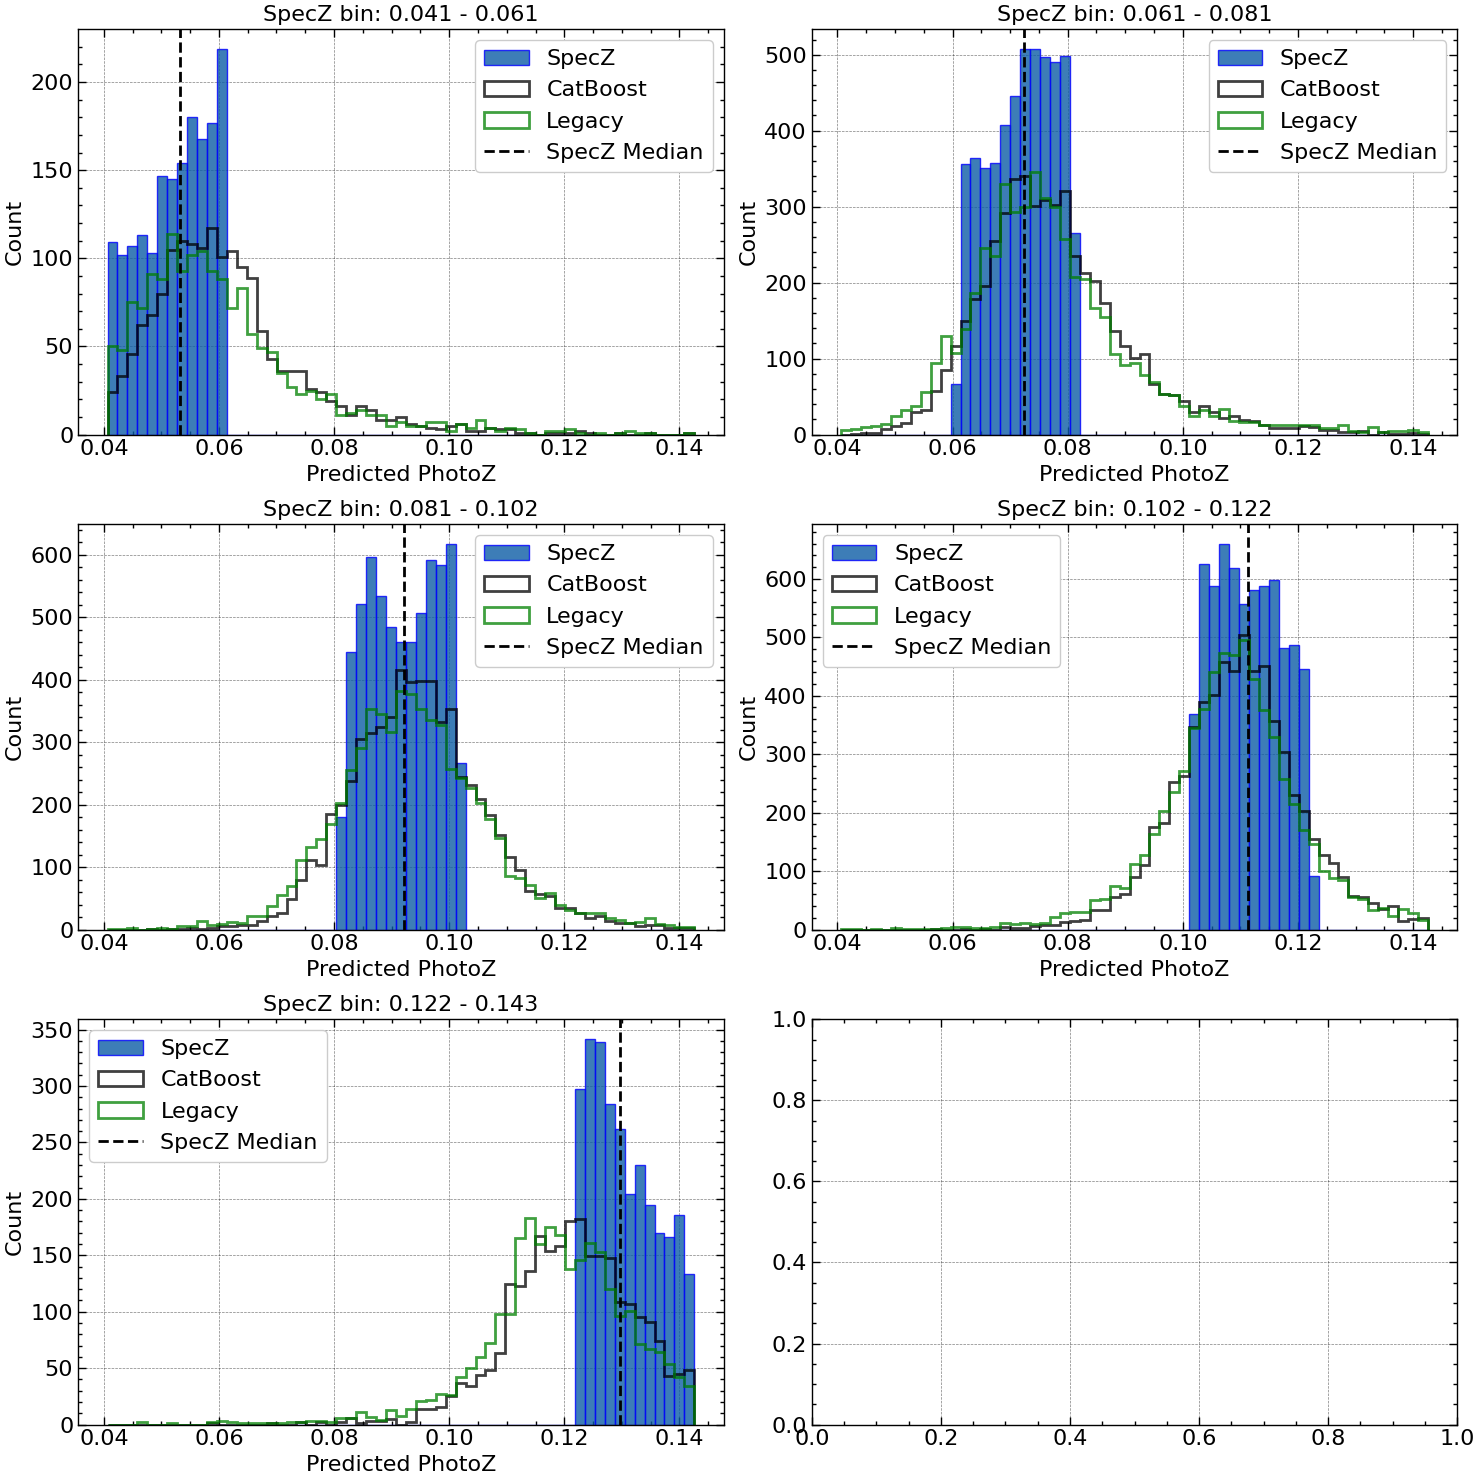

In [84]:
nbins = 5 
zbins = np.linspace(np.percentile(DR1_north_filtered['Z'], 2), np.percentile(DR1_north_filtered['Z'], 95), nbins+1)
bin_indices = np.digitize(DR1_north_filtered['Z'], zbins)

fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()
for i in range(1, nbins+1):
    mask = bin_indices == i
    phot_z_bin  =Z_pred_north[mask]
    spec_z_bin = DR1_north_filtered['Z'][mask]
    phot_z_legacy_bin = matched_north_photoz_filtered['Z_PHOT_MEDIAN'][mask]
    bin_hist = np.linspace(zbins[0],zbins[-1],60)
    axes[i-1].hist(spec_z_bin,bins =bin_hist ,alpha =0.8, label='SpecZ',edgecolor='blue')
    axes[i-1].hist(phot_z_bin,bins =bin_hist ,alpha =0.75, label='CatBoost',histtype='step',edgecolor='k',lw = 2)
    axes[i-1].hist(phot_z_legacy_bin,bins =bin_hist ,alpha =0.75, label='Legacy',histtype='step',edgecolor='green',lw =2)
    axes[i-1].axvline(np.median(spec_z_bin), color='k', linestyle='--', label='SpecZ Median')
    axes[i-1].set_title(f'SpecZ bin: {zbins[i-1]:.3f} - {zbins[i]:.3f}')
    axes[i-1].legend()
    axes[i-1].set_xlabel('Predicted PhotoZ')
    axes[i-1].set_ylabel('Count')   
plt.tight_layout()
plt.show()